# Chapter 4 Computer Lab

## Lines, Planes, Hyperplanes, and Parametric Geometry

This lab accompanies **Chapter 4: Lines, Planes, Hyperplanes, and Parametric Geometry**.

The chapter develops the geometry of flat objects using points and vectors. In this lab, we turn those formulas into computational tools.

### Learning goals

By the end of this lab, you should be able to:

1. Represent lines in $\mathbb R^2$, $\mathbb R^3$, and $\mathbb R^n$ using parametric equations.
2. Convert between direction-vector and normal-vector descriptions of lines and planes.
3. Parameterize line segments and interpret them as interpolation paths.
4. Build planes from point-normal data, three points, or two spanning vectors.
5. Compute line-plane and plane-plane intersections.
6. Compute angles and distances involving lines, planes, and hyperplanes.
7. Use signed distance to interpret linear decision boundaries.
8. Connect affine constraints $Ax=b$ with lines, planes, and higher-dimensional affine subspaces.

### Main idea

A point tells us **where** an object is. A vector tells us **how to move along it** or **which direction is perpendicular to it**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 3D plotting support
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

np.set_printoptions(precision=4, suppress=True)

rng = np.random.default_rng(2321)

print("Libraries loaded.")

Libraries loaded.


## 0. Plotting and geometry helper functions

The following helper functions will be used throughout the lab. They are not the main mathematics, but they keep the visualizations clean.

In [2]:
def set_axes_equal_3d(ax):
    """Make a 3D plot have equal scale on all axes."""
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()

    x_range = abs(x_limits[1] - x_limits[0])
    y_range = abs(y_limits[1] - y_limits[0])
    z_range = abs(z_limits[1] - z_limits[0])

    x_middle = np.mean(x_limits)
    y_middle = np.mean(y_limits)
    z_middle = np.mean(z_limits)

    plot_radius = 0.5 * max([x_range, y_range, z_range])

    ax.set_xlim3d([x_middle - plot_radius, x_middle + plot_radius])
    ax.set_ylim3d([y_middle - plot_radius, y_middle + plot_radius])
    ax.set_zlim3d([z_middle - plot_radius, z_middle + plot_radius])


def draw_axes_2d(ax):
    ax.axhline(0, linewidth=0.8)
    ax.axvline(0, linewidth=0.8)
    ax.grid(True, alpha=0.3)
    ax.set_aspect("equal", adjustable="box")


def unit(v, tol=1e-12):
    """Return the unit vector in the direction of v."""
    v = np.asarray(v, dtype=float)
    length = np.linalg.norm(v)
    if length < tol:
        raise ValueError("The zero vector has no direction.")
    return v / length

## 1. Lines in $\mathbb R^2$

A line through a point $P$ with nonzero direction vector $v$ has the form

$$
r(t)=P+tv.
$$

This formula is dimension independent. In the plane, it means

$$
(x(t),y(t))=(x_0,y_0)+t(a,b).
$$

In [3]:
def line_point(P, v, t):
    """Evaluate the parametric line P + t v."""
    P = np.asarray(P, dtype=float)
    v = np.asarray(v, dtype=float)
    return P + t * v


def line_points(P, v, t_values):
    """Evaluate a line at many parameter values.

    Returns an array whose rows are points.
    """
    P = np.asarray(P, dtype=float)
    v = np.asarray(v, dtype=float)
    t_values = np.asarray(t_values, dtype=float)
    return P[None, :] + t_values[:, None] * v[None, :]

P = np.array([2.0, -1.0])
v = np.array([3.0, 2.0])

for t in [-1, 0, 1, 2]:
    print(f"t = {t:>2}: r(t) = {line_point(P, v, t)}")

t = -1: r(t) = [-1. -3.]
t =  0: r(t) = [ 2. -1.]
t =  1: r(t) = [5. 1.]
t =  2: r(t) = [8. 3.]


### Visualization: a point and a direction vector

The direction vector does not have to start at the origin when we draw it. For a line, it is often most useful to draw it starting at the point $P$.

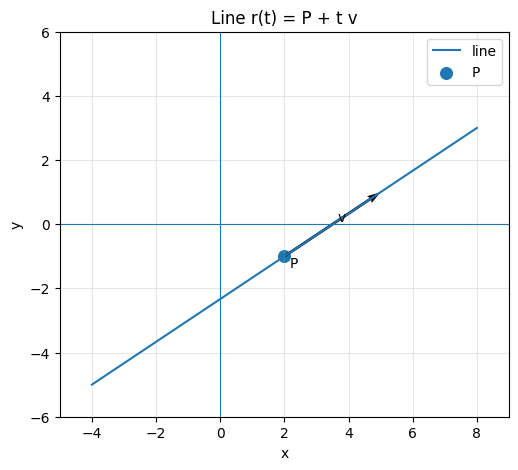

In [4]:
t = np.linspace(-2, 2, 200)
L = line_points(P, v, t)

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.plot(L[:, 0], L[:, 1], label="line")
ax.scatter([P[0]], [P[1]], s=70, label="P")
ax.quiver(P[0], P[1], v[0], v[1], angles="xy", scale_units="xy", scale=1, width=0.006)
ax.text(P[0] + 0.15, P[1] - 0.35, "P")
ax.text(P[0] + 0.55 * v[0], P[1] + 0.55 * v[1], "v")
draw_axes_2d(ax)
ax.set_xlim(-5, 9)
ax.set_ylim(-6, 6)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Line r(t) = P + t v")
ax.legend()
plt.show()

## 2. Direction vectors and normal vectors in the plane

For a line in $\mathbb R^2$, a direction vector points along the line. A normal vector points perpendicular to the line.

If

$$
v=\langle a,b\rangle,
$$

then two possible normal vectors are

$$
\langle -b,a\rangle \quad \text{and} \quad \langle b,-a\rangle.
$$

A line through $P_0$ with normal vector $n$ has point-normal equation

$$
n\cdot (x-P_0)=0.
$$

In [5]:
def normal_from_direction_2d(v):
    """Return one normal vector perpendicular to a 2D direction vector."""
    v = np.asarray(v, dtype=float)
    return np.array([-v[1], v[0]])

n = normal_from_direction_2d(v)
print("Direction vector v:", v)
print("A normal vector n:", n)
print("n dot v =", n @ v)

# Standard form: n dot x + d = 0, where d = -n dot P.
d = -n @ P
print("Standard form coefficients [A, B, C] for A x + B y + C = 0:")
print([n[0], n[1], d])

Direction vector v: [3. 2.]
A normal vector n: [-2.  3.]
n dot v = 0.0
Standard form coefficients [A, B, C] for A x + B y + C = 0:
[np.float64(-2.0), np.float64(3.0), np.float64(7.0)]


### Membership test

A point $X$ lies on the line exactly when $n\cdot X+d=0$.

In [6]:
def line_signed_value_2d(X, n, d):
    X = np.asarray(X, dtype=float)
    n = np.asarray(n, dtype=float)
    return X @ n + d

points_to_test = np.array([
    [2, -1],      # P
    [5, 1],       # P + v
    [3, 4],       # likely not on the line
    [-1, -3],     # P - v
])

for X in points_to_test:
    print(f"X = {X}, signed value = {line_signed_value_2d(X, n, d): .4f}")

X = [ 2 -1], signed value =  0.0000
X = [5 1], signed value =  0.0000
X = [3 4], signed value =  13.0000
X = [-1 -3], signed value =  0.0000


### Task 1: A line through two points

Let

$$
A=(-1,3), \qquad B=(4,-2).
$$

Compute:

1. a direction vector for the line through $A$ and $B$;
2. a normal vector;
3. standard form $Ax+By+C=0$;
4. a plot of the line.

Direction vector B - A: [ 5. -5.]
Normal vector: [5. 5.]
Standard form: 5.0 x + 5.0 y + -10.0 = 0
Check A: 0.0
Check B: 0.0


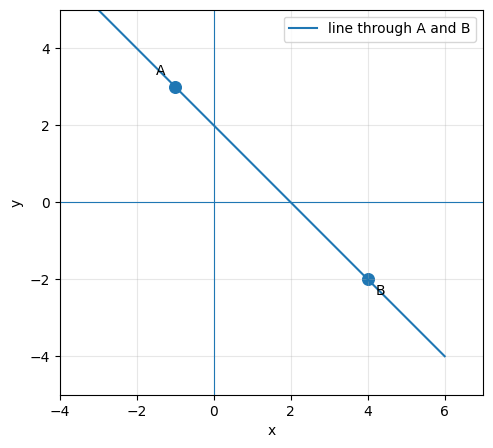

In [7]:
# Reference solution for Task 1
A = np.array([-1.0, 3.0])
B = np.array([4.0, -2.0])

v_AB = B - A
n_AB = normal_from_direction_2d(v_AB)
d_AB = -n_AB @ A

print("Direction vector B - A:", v_AB)
print("Normal vector:", n_AB)
print("Standard form: {:.1f} x + {:.1f} y + {:.1f} = 0".format(n_AB[0], n_AB[1], d_AB))
print("Check A:", n_AB @ A + d_AB)
print("Check B:", n_AB @ B + d_AB)

T = np.linspace(-0.4, 1.4, 100)
line_AB = line_points(A, v_AB, T)

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.plot(line_AB[:, 0], line_AB[:, 1], label="line through A and B")
ax.scatter([A[0], B[0]], [A[1], B[1]], s=70)
ax.text(A[0] - 0.5, A[1] + 0.3, "A")
ax.text(B[0] + 0.2, B[1] - 0.4, "B")
draw_axes_2d(ax)
ax.set_xlim(-4, 7)
ax.set_ylim(-5, 5)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
plt.show()

## 3. Lines in $\mathbb R^3$

A line in three-dimensional space is still

$$
r(t)=P+tv.
$$

If $P=(x_0,y_0,z_0)$ and $v=\langle a,b,c\rangle$, then

$$
x=x_0+at,\qquad y=y_0+bt,\qquad z=z_0+ct.
$$

When $a,b,c$ are nonzero, the same line can be written in symmetric form:

$$
\frac{x-x_0}{a}=\frac{y-y_0}{b}=\frac{z-z_0}{c}.
$$

In [8]:
P3 = np.array([-5.0, 5.0, 4.0])
Q3 = np.array([7.0, -1.0, 2.0])
v3 = Q3 - P3
midpoint = 0.5 * (P3 + Q3)

print("P =", P3)
print("Q =", Q3)
print("Direction vector Q - P =", v3)
print("Length of segment PQ =", np.linalg.norm(v3))
print("Midpoint =", midpoint)

P = [-5.  5.  4.]
Q = [ 7. -1.  2.]
Direction vector Q - P = [12. -6. -2.]
Length of segment PQ = 13.564659966250536
Midpoint = [1. 2. 3.]


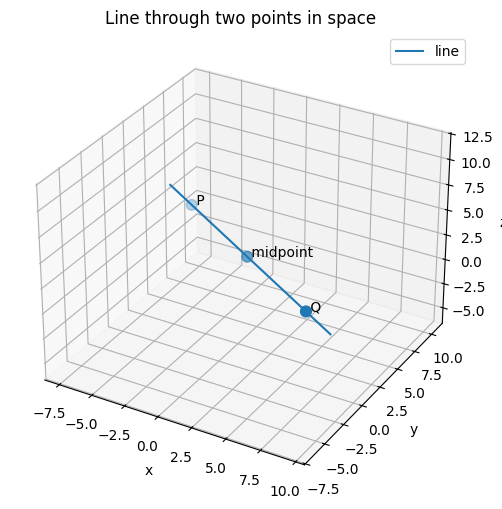

In [9]:
t = np.linspace(-0.2, 1.2, 100)
L3 = line_points(P3, v3, t)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot(L3[:, 0], L3[:, 1], L3[:, 2], label="line")
ax.scatter([P3[0], Q3[0], midpoint[0]], [P3[1], Q3[1], midpoint[1]], [P3[2], Q3[2], midpoint[2]], s=60)
ax.text(P3[0], P3[1], P3[2], " P")
ax.text(Q3[0], Q3[1], Q3[2], " Q")
ax.text(midpoint[0], midpoint[1], midpoint[2], " midpoint")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Line through two points in space")
set_axes_equal_3d(ax)
ax.legend()
plt.show()

### Zero components and symmetric equations

If a component of the direction vector is zero, do **not** divide by that component. Instead, the corresponding coordinate is constant.

For example, the line

$$
r(t)=(2,-3,0)+t(0,0,1)
$$

is parallel to the $z$-axis. It has $x=2$ and $y=-3$ for all $t$.

In [10]:
Pz = np.array([2.0, -3.0, 0.0])
vz = np.array([0.0, 0.0, 1.0])

for t_value in [-2, 0, 3]:
    print(f"t = {t_value}: {line_point(Pz, vz, t_value)}")

t = -2: [ 2. -3. -2.]
t = 0: [ 2. -3.  0.]
t = 3: [ 2. -3.  3.]


## 4. Line segments and interpolation

The line segment from $P$ to $Q$ is

$$
r(t)=P+t(Q-P),\qquad 0\le t\le 1.
$$

Equivalently,

$$
r(t)=(1-t)P+tQ,\qquad 0\le t\le 1.
$$

The second formula emphasizes **linear interpolation**: when $t=0$ we are at $P$, and when $t=1$ we are at $Q$.

In [11]:
def segment_points(P, Q, t_values):
    P = np.asarray(P, dtype=float)
    Q = np.asarray(Q, dtype=float)
    t_values = np.asarray(t_values, dtype=float)
    return (1 - t_values)[:, None] * P[None, :] + t_values[:, None] * Q[None, :]

P_seg = np.array([1.0, 2.0, 3.0])
Q_seg = np.array([4.0, 5.0, 7.0])

for t_value in [0, 0.25, 0.5, 0.75, 1]:
    print(f"t = {t_value:.2f}: {segment_points(P_seg, Q_seg, np.array([t_value]))[0]}")

t = 0.00: [1. 2. 3.]
t = 0.25: [1.75 2.75 4.  ]
t = 0.50: [2.5 3.5 5. ]
t = 0.75: [3.25 4.25 6.  ]
t = 1.00: [4. 5. 7.]


### Interpolation in parameter space

In machine learning, a parameter vector before training and after training can be viewed as two points in a high-dimensional space. A straight interpolation path between them is a line segment.

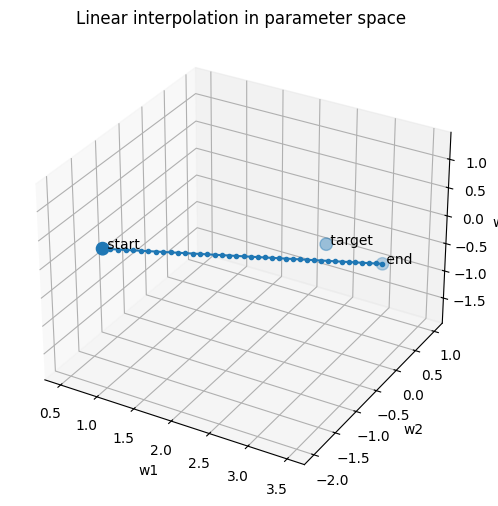

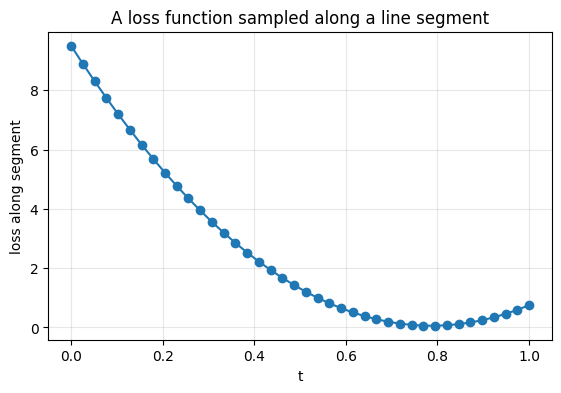

In [12]:
w0 = np.array([1.0, -2.0, 0.5])
w1 = np.array([3.0, 1.0, -1.0])
T = np.linspace(0, 1, 40)
W = segment_points(w0, w1, T)

# A simple quadratic loss landscape centered at w_star.
w_star = np.array([2.5, 0.5, -0.5])
loss = np.sum((W - w_star[None, :]) ** 2, axis=1)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot(W[:, 0], W[:, 1], W[:, 2], marker="o", markersize=3)
ax.scatter([w0[0], w1[0], w_star[0]], [w0[1], w1[1], w_star[1]], [w0[2], w1[2], w_star[2]], s=80)
ax.text(w0[0], w0[1], w0[2], " start")
ax.text(w1[0], w1[1], w1[2], " end")
ax.text(w_star[0], w_star[1], w_star[2], " target")
ax.set_xlabel("w1")
ax.set_ylabel("w2")
ax.set_zlabel("w3")
ax.set_title("Linear interpolation in parameter space")
set_axes_equal_3d(ax)
plt.show()

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(T, loss, marker="o")
ax.set_xlabel("t")
ax.set_ylabel("loss along segment")
ax.set_title("A loss function sampled along a line segment")
ax.grid(True, alpha=0.3)
plt.show()

## 5. Planes in $\mathbb R^3$: point-normal form

A plane in $\mathbb R^3$ is determined by a point $P_0$ and a nonzero normal vector $n$.

The point-normal form is

$$
n\cdot (x-P_0)=0.
$$

If $n=\langle a,b,c\rangle$, this becomes

$$
a(x-x_0)+b(y-y_0)+c(z-z_0)=0.
$$

Expanded form:

$$
ax+by+cz+d=0.
$$

In [13]:
def plane_from_point_normal(P0, normal):
    """Return (normal, d) for the plane normal dot x + d = 0 through P0."""
    P0 = np.asarray(P0, dtype=float)
    normal = np.asarray(normal, dtype=float)
    d = -normal @ P0
    return normal, d


def plane_signed_value(P, normal, d):
    """Return normal dot P + d."""
    P = np.asarray(P, dtype=float)
    normal = np.asarray(normal, dtype=float)
    return normal @ P + d

P0 = np.array([1.0, 2.0, 3.0])
normal = np.array([4.0, 5.0, 6.0])
normal, d = plane_from_point_normal(P0, normal)

print("Plane coefficients:")
print("normal =", normal)
print("d =", d)
print("Equation: 4x + 5y + 6z - 32 = 0")
print("Check P0:", plane_signed_value(P0, normal, d))

Plane coefficients:
normal = [4. 5. 6.]
d = -32.0
Equation: 4x + 5y + 6z - 32 = 0
Check P0: 0.0


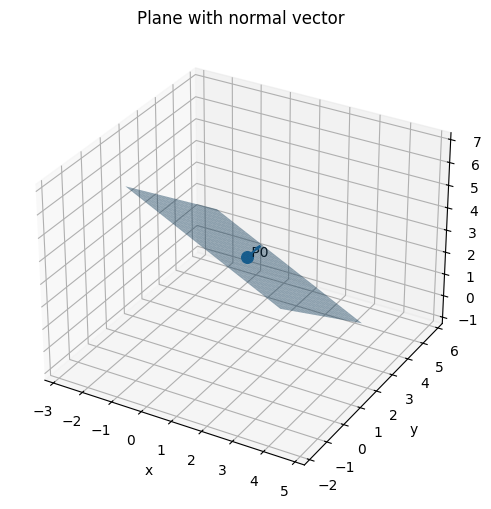

In [14]:
def plane_surface_z(normal, d, xlim=(-3, 5), ylim=(-2, 6), num=25):
    """Create X, Y, Z arrays for normal dot x + d = 0, solving for z.

    This helper assumes the z coefficient is nonzero.
    """
    normal = np.asarray(normal, dtype=float)
    if abs(normal[2]) < 1e-12:
        raise ValueError("Cannot solve for z because the z coefficient is zero.")
    x = np.linspace(xlim[0], xlim[1], num)
    y = np.linspace(ylim[0], ylim[1], num)
    X, Y = np.meshgrid(x, y)
    Z = -(normal[0] * X + normal[1] * Y + d) / normal[2]
    return X, Y, Z

X, Y, Z = plane_surface_z(normal, d, xlim=(-1.5, 3.5), ylim=(-0.5, 4.5))

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X, Y, Z, alpha=0.45, linewidth=0)
ax.scatter([P0[0]], [P0[1]], [P0[2]], s=70)
ax.quiver(P0[0], P0[1], P0[2], normal[0], normal[1], normal[2], length=0.55, normalize=True)
ax.text(P0[0], P0[1], P0[2], " P0")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Plane with normal vector")
set_axes_equal_3d(ax)
plt.show()

## 6. Signed distance and projection onto a plane

For a plane

$$
n\cdot x+d=0,
$$

the signed distance from a point $P$ to the plane is

$$
\frac{n\cdot P+d}{\lVert n\rVert}.
$$

The orthogonal projection of $P$ onto the plane is

$$
P-\frac{n\cdot P+d}{n\cdot n}n.
$$

In [15]:
def plane_signed_distance(P, normal, d):
    P = np.asarray(P, dtype=float)
    normal = np.asarray(normal, dtype=float)
    return (normal @ P + d) / np.linalg.norm(normal)


def project_point_to_plane(P, normal, d):
    P = np.asarray(P, dtype=float)
    normal = np.asarray(normal, dtype=float)
    return P - ((normal @ P + d) / (normal @ normal)) * normal

P_test = np.array([3.0, 1.0, 6.0])
P_proj = project_point_to_plane(P_test, normal, d)

print("Point:", P_test)
print("Signed distance to plane:", plane_signed_distance(P_test, normal, d))
print("Projection onto plane:", P_proj)
print("Plane value at projection:", plane_signed_value(P_proj, normal, d))

Point: [3. 1. 6.]
Signed distance to plane: 2.393172105652397
Projection onto plane: [ 1.9091 -0.3636  4.3636]
Plane value at projection: 0.0


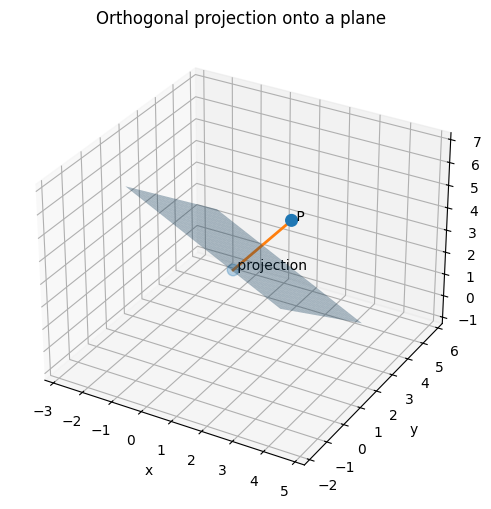

In [16]:
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X, Y, Z, alpha=0.35, linewidth=0)
ax.scatter([P_test[0], P_proj[0]], [P_test[1], P_proj[1]], [P_test[2], P_proj[2]], s=70)
ax.plot([P_test[0], P_proj[0]], [P_test[1], P_proj[1]], [P_test[2], P_proj[2]], linewidth=2)
ax.text(P_test[0], P_test[1], P_test[2], " P")
ax.text(P_proj[0], P_proj[1], P_proj[2], " projection")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Orthogonal projection onto a plane")
set_axes_equal_3d(ax)
plt.show()

## 7. Planes from three points

Three noncollinear points $P,Q,R$ determine a plane. Two direction vectors in the plane are

$$
Q-P, \qquad R-P.
$$

A normal vector is

$$
(Q-P)\times(R-P).
$$

In [17]:
def plane_from_three_points(P, Q, R, tol=1e-12):
    P = np.asarray(P, dtype=float)
    Q = np.asarray(Q, dtype=float)
    R = np.asarray(R, dtype=float)
    u = Q - P
    v = R - P
    normal = np.cross(u, v)
    if np.linalg.norm(normal) < tol:
        raise ValueError("The three points are collinear or repeated; they do not determine a unique plane.")
    d = -normal @ P
    return normal, d, u, v

P = np.array([1.0, 2.0, 3.0])
Q = np.array([2.0, 2.0, 5.0])
R = np.array([3.0, 4.0, 1.0])

n3, d3, u3, v3_plane = plane_from_three_points(P, Q, R)
print("u = Q - P =", u3)
print("v = R - P =", v3_plane)
print("normal = u cross v =", n3)
print("d =", d3)
print("A simplified normal is", n3 / 2)
print("Plane checks:")
for label, point in [("P", P), ("Q", Q), ("R", R)]:
    print(label, plane_signed_value(point, n3, d3))

u = Q - P = [1. 0. 2.]
v = R - P = [ 2.  2. -2.]
normal = u cross v = [-4.  6.  2.]
d = -14.0
A simplified normal is [-2.  3.  1.]
Plane checks:
P 0.0
Q 0.0
R 0.0


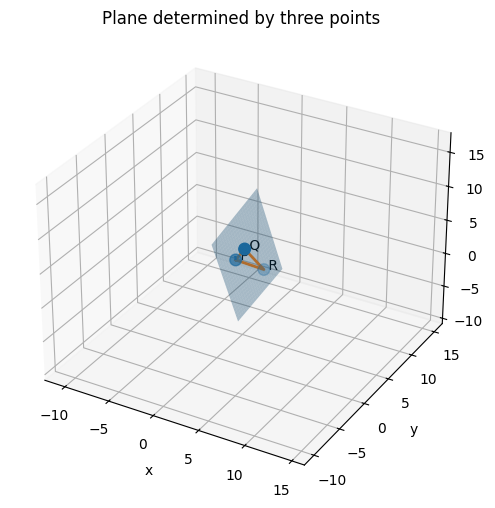

In [18]:
X3, Y3, Z3 = plane_surface_z(n3, d3, xlim=(-0.5, 4.5), ylim=(0, 5))

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X3, Y3, Z3, alpha=0.35, linewidth=0)
ax.scatter([P[0], Q[0], R[0]], [P[1], Q[1], R[1]], [P[2], Q[2], R[2]], s=70)
ax.plot([P[0], Q[0], R[0], P[0]], [P[1], Q[1], R[1], P[1]], [P[2], Q[2], R[2], P[2]], linewidth=2)
ax.quiver(P[0], P[1], P[2], n3[0], n3[1], n3[2], length=0.55, normalize=True)
ax.text(P[0], P[1], P[2], " P")
ax.text(Q[0], Q[1], Q[2], " Q")
ax.text(R[0], R[1], R[2], " R")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Plane determined by three points")
set_axes_equal_3d(ax)
plt.show()

### Task 2: Detect collinearity

The cross product also detects degeneracy. If $(Q-P)\times(R-P)=0$, then the three points are collinear and do not determine a unique plane.

In [19]:
P_col = np.array([0.0, 0.0, 0.0])
Q_col = np.array([1.0, 2.0, 3.0])
R_col = np.array([2.0, 4.0, 6.0])

cross_col = np.cross(Q_col - P_col, R_col - P_col)
print("Cross product:", cross_col)
print("Norm of cross product:", np.linalg.norm(cross_col))
print("Collinear?", np.linalg.norm(cross_col) < 1e-12)

Cross product: [0. 0. 0.]
Norm of cross product: 0.0
Collinear? True


## 8. Parametric form of a plane

A plane can also be described by one point and two nonparallel direction vectors:

$$
r(s,t)=P_0+su+tv.
$$

The normal vector is

$$
n=u\times v.
$$

In [20]:
def parametric_plane_points(P0, u, v, s_values, t_values):
    P0 = np.asarray(P0, dtype=float)
    u = np.asarray(u, dtype=float)
    v = np.asarray(v, dtype=float)
    S, T = np.meshgrid(s_values, t_values)
    X = P0[0] + S * u[0] + T * v[0]
    Y = P0[1] + S * u[1] + T * v[1]
    Z = P0[2] + S * u[2] + T * v[2]
    return X, Y, Z

P0p = np.array([1.0, 0.0, 2.0])
up = np.array([1.0, 2.0, 0.0])
vp = np.array([0.0, 1.0, 3.0])
np_plane = np.cross(up, vp)
dp = -np_plane @ P0p

print("u cross v =", np_plane)
print("Plane equation: {:.1f}x + {:.1f}y + {:.1f}z + {:.1f} = 0".format(np_plane[0], np_plane[1], np_plane[2], dp))

u cross v = [ 6. -3.  1.]
Plane equation: 6.0x + -3.0y + 1.0z + -8.0 = 0


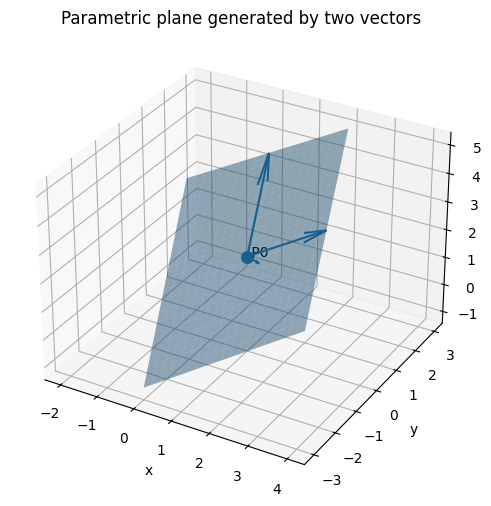

In [21]:
s_values = np.linspace(-1, 1, 20)
t_values = np.linspace(-1, 1, 20)
Xp, Yp, Zp = parametric_plane_points(P0p, up, vp, s_values, t_values)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(Xp, Yp, Zp, alpha=0.45, linewidth=0)
ax.scatter([P0p[0]], [P0p[1]], [P0p[2]], s=70)
ax.quiver(P0p[0], P0p[1], P0p[2], up[0], up[1], up[2], length=1, normalize=False)
ax.quiver(P0p[0], P0p[1], P0p[2], vp[0], vp[1], vp[2], length=1, normalize=False)
ax.quiver(P0p[0], P0p[1], P0p[2], np_plane[0], np_plane[1], np_plane[2], length=0.5, normalize=True)
ax.text(P0p[0], P0p[1], P0p[2], " P0")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Parametric plane generated by two vectors")
set_axes_equal_3d(ax)
plt.show()

## 9. Line-plane intersections

Given a line

$$
r(t)=P+tv
$$

and a plane

$$
n\cdot x+d=0,
$$

substitute the line into the plane:

$$
n\cdot(P+tv)+d=0.
$$

This gives

$$
t=-\frac{n\cdot P+d}{n\cdot v},
$$

provided $n\cdot v\ne 0$.

In [22]:
def line_plane_intersection(P, v, normal, d, tol=1e-12):
    """Classify and compute the intersection of a line and a plane.

    Line: P + t v.
    Plane: normal dot x + d = 0.
    """
    P = np.asarray(P, dtype=float)
    v = np.asarray(v, dtype=float)
    normal = np.asarray(normal, dtype=float)

    denom = normal @ v
    numer = normal @ P + d

    if abs(denom) > tol:
        t = -numer / denom
        point = P + t * v
        return {"status": "unique", "t": t, "point": point}
    if abs(numer) < tol:
        return {"status": "contained", "t": None, "point": None}
    return {"status": "parallel_disjoint", "t": None, "point": None}

# Example: x=1-2t, y=3+t, z=2+4t; plane 2x-y+z=0.
P_line = np.array([1.0, 3.0, 2.0])
v_line = np.array([-2.0, 1.0, 4.0])
n_plane = np.array([2.0, -1.0, 1.0])
d_plane = 0.0

result = line_plane_intersection(P_line, v_line, n_plane, d_plane)
print(result)

{'status': 'unique', 't': np.float64(1.0), 'point': array([-1.,  4.,  6.])}


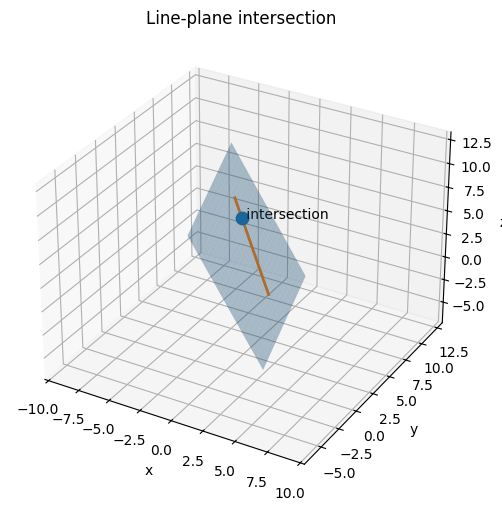

In [23]:
t = np.linspace(-0.5, 1.4, 100)
L = line_points(P_line, v_line, t)
intersection = result["point"]

Xi, Yi, Zi = plane_surface_z(n_plane, d_plane, xlim=(-3, 3), ylim=(0, 6))

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(Xi, Yi, Zi, alpha=0.35, linewidth=0)
ax.plot(L[:, 0], L[:, 1], L[:, 2], linewidth=2)
ax.scatter([intersection[0]], [intersection[1]], [intersection[2]], s=80)
ax.text(intersection[0], intersection[1], intersection[2], " intersection")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Line-plane intersection")
set_axes_equal_3d(ax)
plt.show()

### Task 3: Classify line-plane relationships

A line and plane can have exactly one intersection point, be parallel and disjoint, or the entire line can lie in the plane.

In [24]:
plane_n = np.array([4.0, -9.0, 5.0])
plane_d = -8.0

examples = {
    "parallel but disjoint": (np.array([1.0, 4.0, 5.0]), np.array([1.0, 1.0, 1.0])),
    "contained": (np.array([1.0, 0.0, 0.8]), np.array([1.0, 1.0, 1.0])),
    "unique intersection": (np.array([1.0, 4.0, 5.0]), np.array([1.0, 0.0, 0.0])),
}

for name, (P_ex, v_ex) in examples.items():
    ans = line_plane_intersection(P_ex, v_ex, plane_n, plane_d)
    print(name, "-->", ans)

parallel but disjoint --> {'status': 'parallel_disjoint', 't': None, 'point': None}
contained --> {'status': 'contained', 't': None, 'point': None}
unique intersection --> {'status': 'unique', 't': np.float64(3.75), 'point': array([4.75, 4.  , 5.  ])}


## 10. Intersection of two planes

Two nonparallel planes in $\mathbb R^3$ intersect in a line.

If the planes are

$$
n_1\cdot x=d_1,\qquad n_2\cdot x=d_2,
$$

then the direction of their intersection line is

$$
v=n_1\times n_2.
$$

To find one point on the line, solve the two plane equations simultaneously.

In [25]:
def intersection_two_planes(n1, c1, n2, c2, tol=1e-12):
    """Return a point and direction for n1 dot x = c1 and n2 dot x = c2.

    The returned point is the minimum-norm solution from least squares.
    """
    n1 = np.asarray(n1, dtype=float)
    n2 = np.asarray(n2, dtype=float)
    direction = np.cross(n1, n2)
    if np.linalg.norm(direction) < tol:
        raise ValueError("Planes are parallel or identical; no unique intersection line.")
    A = np.vstack([n1, n2])
    c = np.array([c1, c2], dtype=float)
    point = np.linalg.lstsq(A, c, rcond=None)[0]
    return point, direction

# Planes: x+y+z=3 and 2x+3y+z=8.
n1 = np.array([1.0, 1.0, 1.0])
c1 = 3.0
n2 = np.array([2.0, 3.0, 1.0])
c2 = 8.0

point_on_line, direction_line = intersection_two_planes(n1, c1, n2, c2)
print("One point on the intersection line:", point_on_line)
print("Direction vector:", direction_line)
print("Check plane 1:", n1 @ point_on_line)
print("Check plane 2:", n2 @ point_on_line)

One point on the intersection line: [ 1.  2. -0.]
Direction vector: [-2.  1.  1.]
Check plane 1: 2.999999999999999
Check plane 2: 8.0


In [26]:
# The chapter's parameterization was r(t) = (1,2,0) + t(-2,1,1).
P_chapter = np.array([1.0, 2.0, 0.0])
v_chapter = np.array([-2.0, 1.0, 1.0])

print("Chapter point checks:", n1 @ P_chapter, n2 @ P_chapter)
print("Chapter direction checks:", n1 @ v_chapter, n2 @ v_chapter)
print("Cross-product direction:", direction_line)

Chapter point checks: 3.0 8.0
Chapter direction checks: 0.0 0.0
Cross-product direction: [-2.  1.  1.]


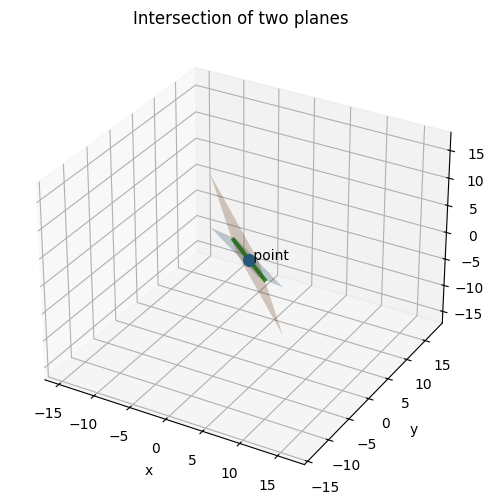

In [27]:
# Visualize the two planes and their intersection line.
x = np.linspace(-2.5, 4, 20)
y = np.linspace(-1, 5, 20)
Xg, Yg = np.meshgrid(x, y)
Z1 = c1 - Xg - Yg
Z2 = c2 - 2 * Xg - 3 * Yg

T = np.linspace(-1.5, 1.5, 100)
L_inter = line_points(P_chapter, v_chapter, T)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(Xg, Yg, Z1, alpha=0.25, linewidth=0)
ax.plot_surface(Xg, Yg, Z2, alpha=0.25, linewidth=0)
ax.plot(L_inter[:, 0], L_inter[:, 1], L_inter[:, 2], linewidth=3)
ax.scatter([P_chapter[0]], [P_chapter[1]], [P_chapter[2]], s=70)
ax.text(P_chapter[0], P_chapter[1], P_chapter[2], " point")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Intersection of two planes")
set_axes_equal_3d(ax)
plt.show()

## 11. Angles involving lines and planes

The angle between two direction vectors $u$ and $v$ is found from

$$
\cos\theta=\frac{u\cdot v}{\lVert u\rVert\lVert v\rVert}.
$$

For the acute angle between two lines, use $|u\cdot v|$.

For the angle between two planes, use the angle between their normal vectors.

In [28]:
def angle_between(u, v, acute=False):
    u = np.asarray(u, dtype=float)
    v = np.asarray(v, dtype=float)
    cos_value = (u @ v) / (np.linalg.norm(u) * np.linalg.norm(v))
    if acute:
        cos_value = abs(cos_value)
    cos_value = np.clip(cos_value, -1.0, 1.0)
    return np.arccos(cos_value)

# Angle between planes x+2y+z=5 and x+y=8.
n1 = np.array([1.0, 2.0, 1.0])
n2 = np.array([1.0, 1.0, 0.0])
theta = angle_between(n1, n2, acute=True)
print("Angle in radians:", theta)
print("Angle in degrees:", np.degrees(theta))
print("Expected: pi/6 =", np.pi / 6)

Angle in radians: 0.5235987755982987
Angle in degrees: 29.999999999999993
Expected: pi/6 = 0.5235987755982988


### Task 4: Angle between two lines

Find the acute angle between two lines with direction vectors

$$
u=\langle 2,-1,2\rangle,\qquad v=\langle 1,3,0\rangle.
$$

In [29]:
u = np.array([2.0, -1.0, 2.0])
v = np.array([1.0, 3.0, 0.0])
angle = angle_between(u, v, acute=True)
print("acute angle in radians:", angle)
print("acute angle in degrees:", np.degrees(angle))
print("cos(theta) =", abs(u @ v) / (np.linalg.norm(u) * np.linalg.norm(v)))

acute angle in radians: 1.4651908866153074
acute angle in degrees: 83.94925398408826
cos(theta) = 0.10540925533894598


## 12. Distance from a point to a line in $\mathbb R^3$

If a line is

$$
r(t)=P_0+tv,
$$

then the distance from $P$ to the line is

$$
\operatorname{dist}(P,L)=\frac{\lVert (P-P_0)\times v\rVert}{\lVert v\rVert}.
$$

The closest point on the line is obtained by projecting $P-P_0$ onto $v$.

In [30]:
def project_point_to_line(P, P0, v):
    P = np.asarray(P, dtype=float)
    P0 = np.asarray(P0, dtype=float)
    v = np.asarray(v, dtype=float)
    t_star = ((P - P0) @ v) / (v @ v)
    closest = P0 + t_star * v
    return closest, t_star


def distance_point_to_line_3d(P, P0, v):
    P = np.asarray(P, dtype=float)
    P0 = np.asarray(P0, dtype=float)
    v = np.asarray(v, dtype=float)
    return np.linalg.norm(np.cross(P - P0, v)) / np.linalg.norm(v)

P = np.array([2.0, 1.0, 4.0])
P0 = np.array([0.0, 0.0, 0.0])
v = np.array([1.0, 2.0, 2.0])
closest, t_star = project_point_to_line(P, P0, v)

distance_formula = distance_point_to_line_3d(P, P0, v)
distance_projection = np.linalg.norm(P - closest)

print("Closest point:", closest)
print("t*:", t_star)
print("Distance from cross-product formula:", distance_formula)
print("Distance from projection:", distance_projection)

Closest point: [1.3333 2.6667 2.6667]
t*: 1.3333333333333333
Distance from cross-product formula: 2.23606797749979
Distance from projection: 2.23606797749979


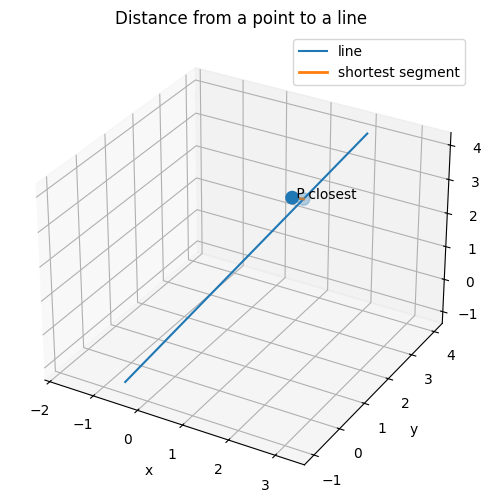

In [31]:
T = np.linspace(-0.5, 2.0, 100)
L = line_points(P0, v, T)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot(L[:, 0], L[:, 1], L[:, 2], label="line")
ax.scatter([P[0], closest[0]], [P[1], closest[1]], [P[2], closest[2]], s=80)
ax.plot([P[0], closest[0]], [P[1], closest[1]], [P[2], closest[2]], linewidth=2, label="shortest segment")
ax.text(P[0], P[1], P[2], " P")
ax.text(closest[0], closest[1], closest[2], " closest")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Distance from a point to a line")
set_axes_equal_3d(ax)
ax.legend()
plt.show()

## 13. Distance from a point to a plane: a numerical check

For the plane

$$
2x-y+2z-5=0
$$

and point $P=(1,2,3)$, the chapter formula gives

$$
\frac{|2(1)-2+2(3)-5|}{\sqrt{2^2+(-1)^2+2^2}}=\frac{1}{3}.
$$

In [32]:
P = np.array([1.0, 2.0, 3.0])
n = np.array([2.0, -1.0, 2.0])
d = -5.0

signed = plane_signed_distance(P, n, d)
proj = project_point_to_plane(P, n, d)

print("signed distance:", signed)
print("ordinary distance:", abs(signed))
print("projection:", proj)
print("projection check:", n @ proj + d)

signed distance: 0.3333333333333333
ordinary distance: 0.3333333333333333
projection: [0.7778 2.1111 2.7778]
projection check: 0.0


## 14. Hyperplanes in $\mathbb R^n$

A hyperplane in $\mathbb R^n$ has equation

$$
w\cdot x+b=0,
$$

where $w\ne 0$.

Its signed distance function is

$$
\frac{w\cdot x+b}{\lVert w\rVert}.
$$

This is the same formula for lines in $\mathbb R^2$, planes in $\mathbb R^3$, and hyperplanes in higher-dimensional spaces.

In [33]:
def hyperplane_signed_distance(X, w, b):
    """Signed distance from one or many points X to w dot x + b = 0.

    X may be a 1D array representing one point, or a 2D array whose rows are points.
    """
    X = np.asarray(X, dtype=float)
    w = np.asarray(w, dtype=float)
    return (X @ w + b) / np.linalg.norm(w)


def project_point_to_hyperplane(x, w, b):
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    return x - ((w @ x + b) / (w @ w)) * w

w4 = np.array([2.0, -1.0, 3.0, 4.0])
b4 = -5.0
x4 = np.array([1.0, 0.0, 2.0, -1.0])

print("w dot x + b =", w4 @ x4 + b4)
print("signed distance =", hyperplane_signed_distance(x4, w4, b4))
print("expected =", -1 / np.sqrt(30))
print("projection onto hyperplane =", project_point_to_hyperplane(x4, w4, b4))
print("check projection:", project_point_to_hyperplane(x4, w4, b4) @ w4 + b4)

w dot x + b = -1.0
signed distance = -0.18257418583505536
expected = -0.18257418583505536
projection onto hyperplane = [ 1.0667 -0.0333  2.1    -0.8667]
check projection: 0.0


## 15. Hyperplanes as linear decision boundaries

A linear classifier predicts the label by the sign of

$$
w\cdot x+b.
$$

The boundary between the two predicted classes is the hyperplane

$$
w\cdot x+b=0.
$$

In two dimensions this boundary is a line.

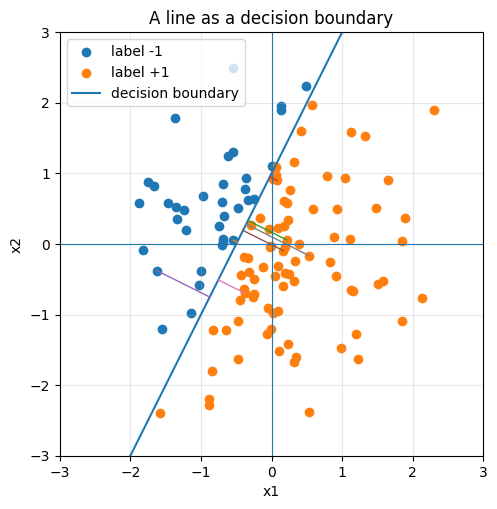

First 10 signed distances: [-0.06   0.952  0.721 -0.214  0.022  2.085  0.134  1.477  0.903 -1.495]


In [34]:
# Generate random points in the plane.
X_data = rng.normal(size=(120, 2))
w = np.array([2.0, -1.0])
b = 1.0
scores = X_data @ w + b
labels = np.where(scores >= 0, 1, -1)
distances = hyperplane_signed_distance(X_data, w, b)

xx = np.linspace(-3, 3, 200)
yy = -(w[0] * xx + b) / w[1]

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(X_data[labels == -1, 0], X_data[labels == -1, 1], label="label -1")
ax.scatter(X_data[labels == 1, 0], X_data[labels == 1, 1], label="label +1")
ax.plot(xx, yy, label="decision boundary")

# Draw perpendicular distance segments for several points.
for p in X_data[::18]:
    foot = project_point_to_hyperplane(p, w, b)
    ax.plot([p[0], foot[0]], [p[1], foot[1]], linewidth=1)

draw_axes_2d(ax)
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("A line as a decision boundary")
ax.legend()
plt.show()

print("First 10 signed distances:", np.round(distances[:10], 3))

### The same idea in $\mathbb R^3$

In three dimensions, a hyperplane is an ordinary plane. The equation

$$
x+y+z=0.2
$$

can be used as a decision boundary in three-feature space.

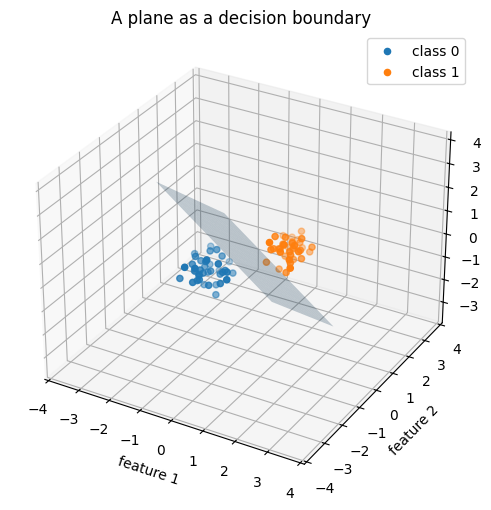

In [35]:
A3 = rng.normal(loc=[-1.0, -0.6, -0.4], scale=0.35, size=(40, 3))
B3 = rng.normal(loc=[1.0, 0.7, 0.5], scale=0.35, size=(40, 3))

w3 = np.array([1.0, 1.0, 1.0])
b3 = -0.2
x = np.linspace(-1.8, 1.8, 18)
y = np.linspace(-1.8, 1.8, 18)
Xg, Yg = np.meshgrid(x, y)
Zg = -(w3[0] * Xg + w3[1] * Yg + b3) / w3[2]

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(A3[:, 0], A3[:, 1], A3[:, 2], label="class 0")
ax.scatter(B3[:, 0], B3[:, 1], B3[:, 2], label="class 1")
ax.plot_surface(Xg, Yg, Zg, alpha=0.25, linewidth=0)
ax.set_xlabel("feature 1")
ax.set_ylabel("feature 2")
ax.set_zlabel("feature 3")
ax.set_title("A plane as a decision boundary")
set_axes_equal_3d(ax)
ax.legend()
plt.show()

## 16. Affine subspaces and linear constraints

A linear subspace passes through the origin. An affine subspace is a shifted linear subspace:

$$
p+\operatorname{span}\{v_1,\dots,v_k\}.
$$

A consistent linear system

$$
Ax=b
$$

describes an affine subspace. In $\mathbb R^3$, two independent linear equations usually describe a line.

In [36]:
def nullspace(A, tol=1e-12):
    """Compute an orthonormal basis for the nullspace of A using SVD."""
    A = np.asarray(A, dtype=float)
    U, s, Vh = np.linalg.svd(A)
    rank = np.sum(s > tol)
    return Vh[rank:].T

# Same two-plane intersection as before: x+y+z=3, 2x+3y+z=8.
A = np.array([[1.0, 1.0, 1.0],
              [2.0, 3.0, 1.0]])
b = np.array([3.0, 8.0])

x_particular = np.linalg.lstsq(A, b, rcond=None)[0]
N = nullspace(A)

print("One solution x_p:", x_particular)
print("A x_p:", A @ x_particular)
print("Nullspace basis:")
print(N)
print("A times nullspace basis:")
print(A @ N)

One solution x_p: [ 1.  2. -0.]
A x_p: [3. 8.]
Nullspace basis:
[[-0.8165]
 [ 0.4082]
 [ 0.4082]]
A times nullspace basis:
[[0.]
 [0.]]


The solution set has the form

$$
x=x_p+t v,
$$

where $v$ spans the nullspace of $A$.

In [37]:
v_null = N[:, 0]
T = np.linspace(-4, 4, 9)
solutions = x_particular[None, :] + T[:, None] * v_null[None, :]

print("Sample solutions of Ax=b:")
for sol in solutions[::2]:
    print(sol, " -> A sol =", A @ sol)

Sample solutions of Ax=b:
[ 4.266  0.367 -1.633]  -> A sol = [3. 8.]
[ 2.633   1.1835 -0.8165]  -> A sol = [3. 8.]
[ 1.  2. -0.]  -> A sol = [3. 8.]
[-0.633   2.8165  0.8165]  -> A sol = [3. 8.]
[-2.266  3.633  1.633]  -> A sol = [3. 8.]


### Projection onto an affine constraint set

The closest point to $p$ subject to $Ax=b$ is

$$
p-A^T(AA^T)^{-1}(Ap-b),
$$

when $A$ has independent rows.

In [38]:
def project_to_affine_constraints(p, A, b):
    p = np.asarray(p, dtype=float)
    A = np.asarray(A, dtype=float)
    b = np.asarray(b, dtype=float)
    correction = A.T @ np.linalg.solve(A @ A.T, A @ p - b)
    return p - correction

p = np.array([3.0, -1.0, 5.0])
p_proj = project_to_affine_constraints(p, A, b)

print("Original point:", p)
print("Projected point:", p_proj)
print("A projected point:", A @ p_proj)
print("Distance moved:", np.linalg.norm(p - p_proj))

Original point: [ 3. -1.  5.]
Projected point: [ 1.6667  1.6667 -0.3333]
A projected point: [3. 8.]
Distance moved: 6.110100926607787


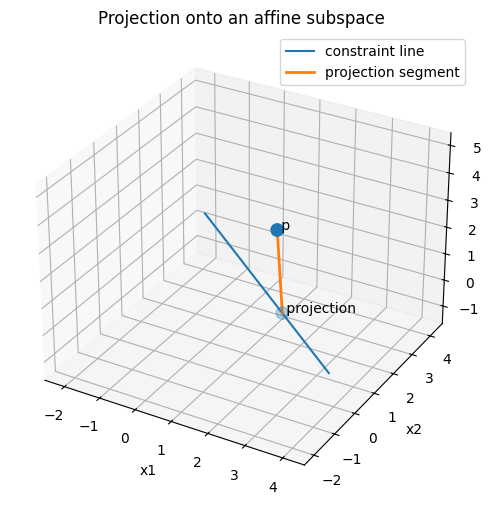

In [39]:
# Visualize projection to the affine line Ax=b.
T = np.linspace(-3, 3, 100)
line_affine = x_particular[None, :] + T[:, None] * v_null[None, :]

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot(line_affine[:, 0], line_affine[:, 1], line_affine[:, 2], label="constraint line")
ax.scatter([p[0], p_proj[0]], [p[1], p_proj[1]], [p[2], p_proj[2]], s=80)
ax.plot([p[0], p_proj[0]], [p[1], p_proj[1]], [p[2], p_proj[2]], linewidth=2, label="projection segment")
ax.text(p[0], p[1], p[2], " p")
ax.text(p_proj[0], p_proj[1], p_proj[2], " projection")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("x3")
ax.set_title("Projection onto an affine subspace")
set_axes_equal_3d(ax)
ax.legend()
plt.show()

## 17. Mini-project: train a simple linear classifier

We now use the hyperplane idea to train a simple classifier in two dimensions.

The perceptron algorithm updates a decision boundary whenever it misclassifies a point. It is not the main focus of this chapter, but it is a useful illustration of hyperplanes as computational objects.

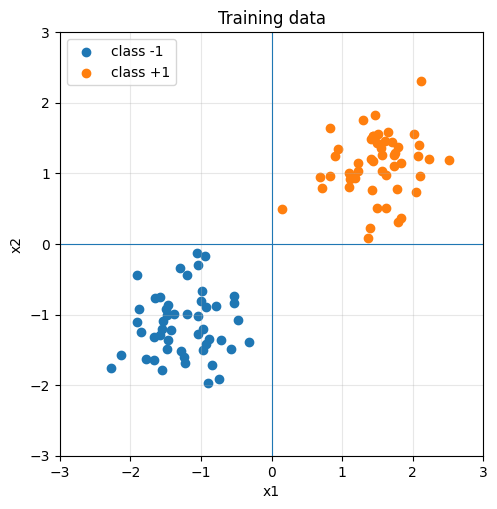

In [40]:
# Create linearly separable synthetic data.
rng = np.random.default_rng(411)
X_pos = rng.normal(loc=[1.5, 1.2], scale=0.45, size=(50, 2))
X_neg = rng.normal(loc=[-1.2, -1.0], scale=0.45, size=(50, 2))
X_train = np.vstack([X_pos, X_neg])
y_train = np.array([1] * len(X_pos) + [-1] * len(X_neg))

# Shuffle the data.
perm = rng.permutation(len(X_train))
X_train = X_train[perm]
y_train = y_train[perm]

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(X_train[y_train == -1, 0], X_train[y_train == -1, 1], label="class -1")
ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], label="class +1")
draw_axes_2d(ax)
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("Training data")
ax.legend()
plt.show()

In [41]:
def perceptron_fit(X, y, epochs=20, learning_rate=1.0):
    w = np.zeros(X.shape[1])
    b = 0.0
    mistakes_by_epoch = []

    for _ in range(epochs):
        mistakes = 0
        for xi, yi in zip(X, y):
            if yi * (w @ xi + b) <= 0:
                w = w + learning_rate * yi * xi
                b = b + learning_rate * yi
                mistakes += 1
        mistakes_by_epoch.append(mistakes)
    return w, b, np.array(mistakes_by_epoch)

w_learned, b_learned, mistakes = perceptron_fit(X_train, y_train, epochs=20, learning_rate=1.0)

pred = np.where(X_train @ w_learned + b_learned >= 0, 1, -1)
accuracy = np.mean(pred == y_train)

print("learned w:", w_learned)
print("learned b:", b_learned)
print("training accuracy:", accuracy)
print("mistakes by epoch:", mistakes)

learned w: [1.5052 1.5543]
learned b: 1.0
training accuracy: 1.0
mistakes by epoch: [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


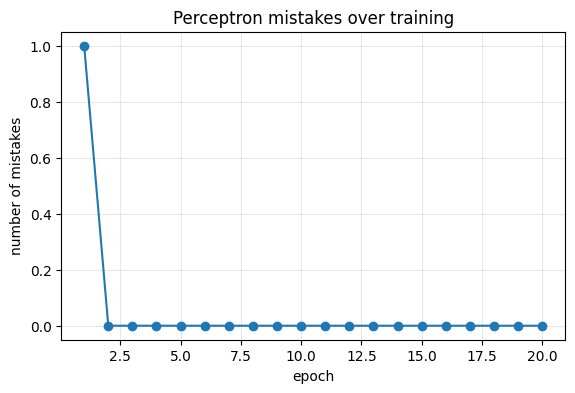

In [42]:
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(np.arange(1, len(mistakes) + 1), mistakes, marker="o")
ax.set_xlabel("epoch")
ax.set_ylabel("number of mistakes")
ax.set_title("Perceptron mistakes over training")
ax.grid(True, alpha=0.3)
plt.show()

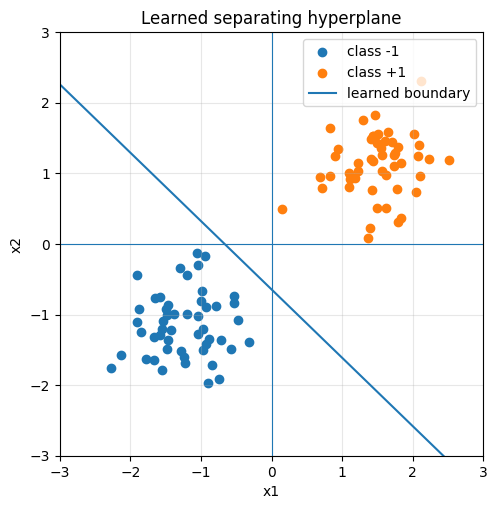

In [43]:
def plot_decision_boundary_2d(ax, w, b, xlim=(-3, 3), label="boundary"):
    xx = np.linspace(xlim[0], xlim[1], 200)
    if abs(w[1]) > 1e-12:
        yy = -(w[0] * xx + b) / w[1]
        ax.plot(xx, yy, label=label)
    else:
        x_vertical = -b / w[0]
        ax.axvline(x_vertical, label=label)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(X_train[y_train == -1, 0], X_train[y_train == -1, 1], label="class -1")
ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], label="class +1")
plot_decision_boundary_2d(ax, w_learned, b_learned, label="learned boundary")
draw_axes_2d(ax)
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("Learned separating hyperplane")
ax.legend()
plt.show()

### Inspect signed distances

The sign of $w\cdot x+b$ gives the predicted class. The magnitude of the signed distance gives how far the point is from the boundary.

Minimum signed distance for class +1: 0.9297066765323887
Maximum signed distance for class -1: -0.31482486760412276


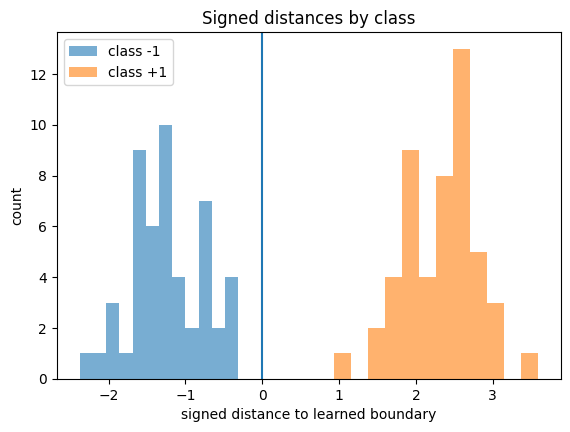

In [44]:
signed_dist = hyperplane_signed_distance(X_train, w_learned, b_learned)

print("Minimum signed distance for class +1:", np.min(signed_dist[y_train == 1]))
print("Maximum signed distance for class -1:", np.max(signed_dist[y_train == -1]))

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.hist(signed_dist[y_train == -1], bins=12, alpha=0.6, label="class -1")
ax.hist(signed_dist[y_train == 1], bins=12, alpha=0.6, label="class +1")
ax.axvline(0, linewidth=1.5)
ax.set_xlabel("signed distance to learned boundary")
ax.set_ylabel("count")
ax.set_title("Signed distances by class")
ax.legend()
plt.show()

## 18. Review exercises

Use the functions in this lab to solve the following.

1. Find a standard equation for the line through $(3,1)$ with direction vector $\langle -2,5\rangle$.
2. Find the intersection of the line $r(t)=(0,1,2)+t(1,-1,3)$ with the plane $x+2y-z=4$.
3. Find the distance from $P=(2,-1,4)$ to the plane $3x-y+2z-10=0$.
4. Find a normal vector to the plane through $(1,0,0)$, $(0,1,0)$, and $(0,0,1)$.
5. In $\mathbb R^5$, compute the signed distance from $x=(1,2,0,-1,3)$ to $w\cdot x+b=0$, where $w=(2,0,-1,1,4)$ and $b=-7$.

In [45]:
# Reference solutions for the review exercises

# 1. Standard equation for the line.
P = np.array([3.0, 1.0])
v = np.array([-2.0, 5.0])
n = normal_from_direction_2d(v)
d = -n @ P
print("1. Line standard form coefficients:", [n[0], n[1], d])

# 2. Line-plane intersection.
P_line = np.array([0.0, 1.0, 2.0])
v_line = np.array([1.0, -1.0, 3.0])
n_plane = np.array([1.0, 2.0, -1.0])
d_plane = -4.0
print("2. Intersection:", line_plane_intersection(P_line, v_line, n_plane, d_plane))

# 3. Distance to plane.
P = np.array([2.0, -1.0, 4.0])
n = np.array([3.0, -1.0, 2.0])
d = -10.0
print("3. Distance:", abs(plane_signed_distance(P, n, d)))

# 4. Plane through intercept points.
P = np.array([1.0, 0.0, 0.0])
Q = np.array([0.0, 1.0, 0.0])
R = np.array([0.0, 0.0, 1.0])
n, d, _, _ = plane_from_three_points(P, Q, R)
print("4. Normal vector:", n, "d:", d)

# 5. Signed distance in R^5.
x = np.array([1.0, 2.0, 0.0, -1.0, 3.0])
w = np.array([2.0, 0.0, -1.0, 1.0, 4.0])
b = -7.0
print("5. Signed distance in R^5:", hyperplane_signed_distance(x, w, b))

1. Line standard form coefficients: [np.float64(-5.0), np.float64(-2.0), np.float64(17.0)]
2. Intersection: {'status': 'unique', 't': np.float64(-1.0), 'point': array([-1.,  2., -1.])}
3. Distance: 1.3363062095621219
4. Normal vector: [1. 1. 1.] d: -1.0
5. Signed distance in R^5: 1.2792042981336627


## 19. Lab summary

In this lab, we built a computational toolkit for flat geometry.

Key formulas:

- Line: $r(t)=P+tv$.
- Segment: $r(t)=(1-t)P+tQ$, $0\le t\le 1$.
- Plane: $n\cdot(x-P_0)=0$ or $n\cdot x+d=0$.
- Parametric plane: $r(s,t)=P_0+su+tv$.
- Hyperplane: $w\cdot x+b=0$.
- Signed distance to a hyperplane: $(w\cdot x+b)/\lVert w\rVert$.
- Projection to a hyperplane: $x-((w\cdot x+b)/(w\cdot w))w$.
- Direction of intersection of two planes: $n_1\times n_2$.

The most important computational lesson is that the same formulas work in many settings: geometry, tangent planes, constraints, optimization, linear regression, classification, and machine learning.